In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
from pathlib import Path

_BASE = Path("../data/synthetic_enrichment")

delayed_rewards = pd.read_csv(_BASE / "delayed_rewards.csv")
offer_catalog   = pd.read_csv(_BASE / "offer_catalog.csv")
offer_events    = pd.read_csv(_BASE / "offer_events.csv")

In [17]:
delayed_rewards

,event_id,subject_key,occurred_at,channel,arm_id,arm_name,reward,delay_days,reward_observed_at,reward_type,reward_status
0,evt_000001,subject_000001,2025-01-01 00:00:00,whatsapp,0,sem_oferta,0,6,2025-01-07 00:00:00,sem_conversao_observada,not_converted
1,evt_000002,subject_000002,2025-01-01 00:01:00,email,3,cartao_premium,0,4,2025-01-05 00:01:00,sem_conversao_observada,not_converted
2,evt_000003,subject_000003,2025-01-01 00:02:00,whatsapp,2,simulador_credito,0,6,2025-01-07 00:02:00,sem_conversao_observada,not_converted
3,evt_000004,subject_000004,2025-01-01 00:03:00,web,1,educacao_financeira,0,5,2025-01-06 00:03:00,sem_conversao_observada,not_converted
4,evt_000005,subject_000005,2025-01-01 00:04:00,email,1,educacao_financeira,0,4,2025-01-05 00:04:00,sem_conversao_observada,not_converted
...,...,...,...,...,...,...,...,...,...,...,...
41183,evt_041184,subject_041184,2025-01-29 14:23:00,app,1,educacao_financeira,1,6,2025-02-04 14:23:00,conversao_confirmada,confirmed
41184,evt_041185,subject_041185,2025-01-29 14:24:00,app,0,sem_oferta,0,1,2025-01-30 14:24:00,sem_conversao_observada,not_converted
41185,evt_041186,subject_041186,2025-01-29 14:25:00,email,2,simulador_credito,0,3,2025-02-01 14:25:00,sem_conversao_observada,not_converted
41186,evt_041187,subject_041187,2025-01-29 14:26:00,whatsapp,1,educacao_financeira,1,5,2025-02-03 14:26:00,conversao_confirmada,confirmed


In [18]:
offer_catalog["arm_name"].value_counts()

arm_name
sem_oferta             1
educacao_financeira    1
simulador_credito      1
cartao_premium         1
Name: count, dtype: int64

In [19]:
offer_events.shape

(41188, 29)

In [20]:
offer_events[["event_id", "subject_key", "channel", "arm_name", "reward"]].head()

,event_id,subject_key,channel,arm_name,reward
0,evt_000001,subject_000001,whatsapp,sem_oferta,0
1,evt_000002,subject_000002,email,cartao_premium,0
2,evt_000003,subject_000003,whatsapp,simulador_credito,0
3,evt_000004,subject_000004,web,educacao_financeira,0
4,evt_000005,subject_000005,email,educacao_financeira,0


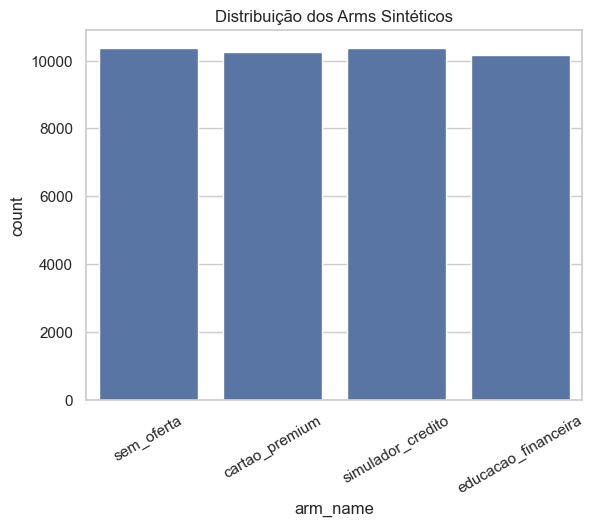

In [21]:
ax = sns.countplot(data=offer_events, x="arm_name")
plt.title("Distribuição dos Arms Sintéticos")
plt.xticks(rotation=30)
plt.show()

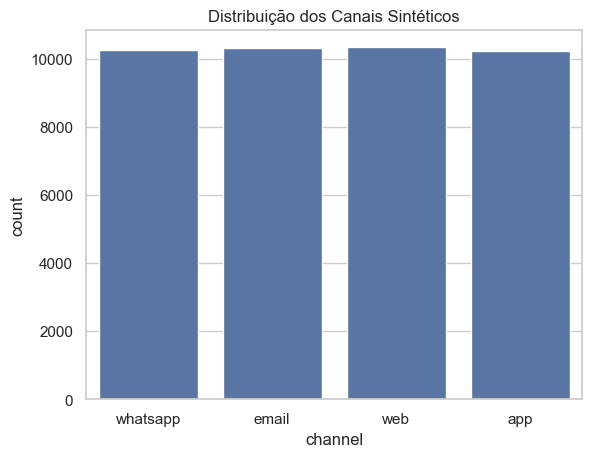

In [22]:
ax = sns.countplot(data=offer_events, x="channel")
plt.title("Distribuição dos Canais Sintéticos")
plt.show()

In [23]:
offer_events["reward"].value_counts(normalize=True)

reward
0    0.887346
1    0.112654
Name: proportion, dtype: float64

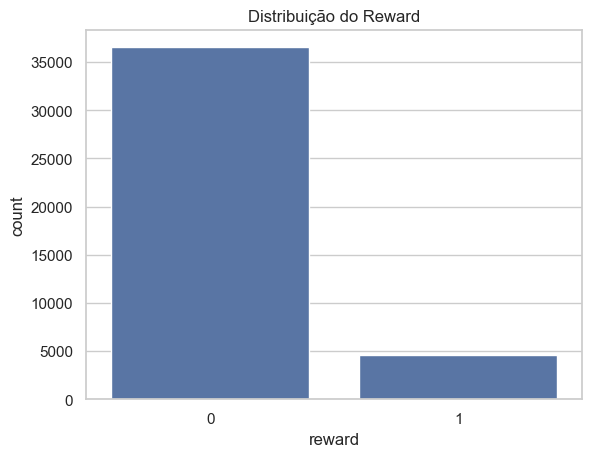

In [24]:
sns.countplot(data=offer_events, x="reward")
plt.title("Distribuição do Reward")
plt.show()

In [25]:
delayed_rewards.head()

,event_id,subject_key,occurred_at,channel,arm_id,arm_name,reward,delay_days,reward_observed_at,reward_type,reward_status
0,evt_000001,subject_000001,2025-01-01 00:00:00,whatsapp,0,sem_oferta,0,6,2025-01-07 00:00:00,sem_conversao_observada,not_converted
1,evt_000002,subject_000002,2025-01-01 00:01:00,email,3,cartao_premium,0,4,2025-01-05 00:01:00,sem_conversao_observada,not_converted
2,evt_000003,subject_000003,2025-01-01 00:02:00,whatsapp,2,simulador_credito,0,6,2025-01-07 00:02:00,sem_conversao_observada,not_converted
3,evt_000004,subject_000004,2025-01-01 00:03:00,web,1,educacao_financeira,0,5,2025-01-06 00:03:00,sem_conversao_observada,not_converted
4,evt_000005,subject_000005,2025-01-01 00:04:00,email,1,educacao_financeira,0,4,2025-01-05 00:04:00,sem_conversao_observada,not_converted


In [26]:
delayed_rewards["delay_days"].describe()

count    41188.000000
mean         4.404171
std          2.581118
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: delay_days, dtype: float64

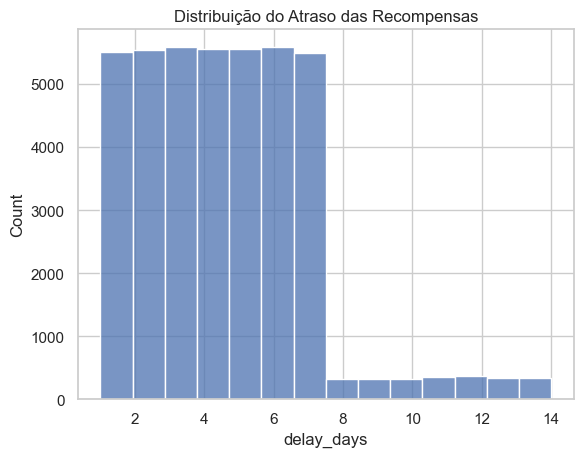

In [27]:
sns.histplot(data=delayed_rewards, x="delay_days", bins=14)
plt.title("Distribuição do Atraso das Recompensas")
plt.show()

In [28]:
offer_events["event_id"].is_unique

True

In [29]:
delayed_rewards["event_id"].is_unique

True

In [31]:
offer_events["event_id"].isin(delayed_rewards["event_id"]).mean()

np.float64(1.0)

## Conclusão

A camada sintética foi criada com sucesso, contendo:

- catálogo de 4 braços de decisão;
- 4 canais digitais simulados;
- eventos sintéticos de oferta;
- reward derivado da variável conversão;
- recompensas atrasadas simuladas;
- chaves rastreáveis por `event_id`.

Essa camada transforma a base original em um ambiente adequado para simulação de políticas adaptativas, permitindo a comparação entre baseline determinístico e algoritmos de Multi-Armed Bandits.